# 02 — Feature Engineering

**Goal:** Build the feature matrix used by both the supervised predictor and the RL agent.

**Key decisions from EDA:**
- Drop 66 dead-electrode columns + 4 null columns + constant columns
- Keep 20 live EEG columns (F3/F4/C3/C4 × Alpha/Gamma/HighBeta/LowBeta/Theta)
- Z-score EEG relative to subsession 0 (personalised baseline normalisation)
- Add lag features (t-1, t-2, t-5) and rolling stats (w=5, 10, 20)
- Action space: discretise ProtocolValue trend into 3 bins (Lower/Hold/Raise)

**Output:** `../data/processed/features.parquet` + `feature_meta.json`

In [1]:
import sys, json, warnings
sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from pathlib import Path

warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../data/processed')
FIGURES_DIR   = Path('../outputs/figures')
TARGET     = 'ProtocolValue'
SS_COL     = 'subsession'
SAMPLE_COL = 'sample_idx'

plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.labelcolor':'#e6edf3','xtick.color':'#8b949e',
    'ytick.color':'#8b949e','text.color':'#e6edf3',
    'grid.color':'#21262d','grid.linestyle':'--','font.family':'monospace'
})
print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
df = pd.read_parquet(PROCESSED_DIR / 'processed_data.parquet')
df = df.sort_values([SS_COL, SAMPLE_COL]).reset_index(drop=True)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols')

Loaded: 3,549 rows x 157 cols


## 2. Column Pruning

In [3]:
DEAD_ELECTRODES = ['AF3','AF4','F7','F8','FC5','FC6','Fp1','Fp2',
                   'O1','O2','Oz','P7','P8','Pz','T7','T8']
DEAD_SUFFIXES   = ['Alpha','Gamma','HighBeta','LowBeta','Theta','SignalQuality']
dead_cols   = [f'{e}{s}' for e in DEAD_ELECTRODES for s in DEAD_SUFFIXES if f'{e}{s}' in df.columns]
null_cols   = [c for c in df.columns if df[c].isna().all()]
const_cols  = [c for c in df.columns if df[c].nunique() <= 1 and c not in null_cols]
meta_cols   = ['Timestamp','Annotations','AudioTracks','session_type',
               'AsteroidPositionX','AsteroidPositionY','RecoveryOffsetFromBaseline']
meta_cols   = [c for c in meta_cols if c in df.columns]

DROP = list(set(dead_cols + null_cols + const_cols + meta_cols))
df_clean = df.drop(columns=[c for c in DROP if c in df.columns])
print(f'Dropped {len(DROP)} cols → {df_clean.shape[1]} remaining')

Dropped 107 cols → 50 remaining


## 3. Feature Groups

In [4]:
LIVE_EL  = ['F3','F4','C3','C4']
BANDS    = ['Alpha','Gamma','HighBeta','LowBeta','Theta']
EEG_COLS = [f'{e}{b}' for e in LIVE_EL for b in BANDS if f'{e}{b}' in df_clean.columns]
SQ_COLS  = [c for c in df_clean.columns if 'SignalQuality' in c and any(e in c for e in LIVE_EL)]
GAME_COLS= [c for c in ['PlayerPositionY','Morale','LevelProgress','OngoingAsteroid'] if c in df_clean.columns]
print(f'EEG: {len(EEG_COLS)} | SQ: {len(SQ_COLS)} | Game: {GAME_COLS}')

EEG: 20 | SQ: 4 | Game: ['PlayerPositionY', 'Morale', 'LevelProgress', 'OngoingAsteroid']


## 4. Baseline Z-Score Normalisation

In [5]:
bl_stats = df_clean[df_clean[SS_COL]==0][EEG_COLS].agg(['mean','std'])
df_feat  = df_clean.copy()
for col in EEG_COLS:
    mu, std = bl_stats.loc['mean',col], bl_stats.loc['std',col]
    df_feat[f'{col}_z'] = (df_feat[col] - mu) / std if std > 1e-8 else 0.0
EEG_Z = [f'{c}_z' for c in EEG_COLS]
print(f'Created {len(EEG_Z)} z-normalised EEG columns')

Created 20 z-normalised EEG columns


## 5. Lag & Rolling Features

In [6]:
LAGS = [1,2,5]; WINDOWS = [5,10,20]
TO_LAG = [TARGET] + EEG_Z + GAME_COLS
TO_LAG = [c for c in TO_LAG if c in df_feat.columns]

for col in TO_LAG:
    for lag in LAGS:
        df_feat[f'{col}_lag{lag}'] = df_feat.groupby(SS_COL)[col].shift(lag)

for col in [TARGET] + EEG_Z:
    for w in WINDOWS:
        df_feat[f'{col}_rmean{w}'] = df_feat.groupby(SS_COL)[col].transform(
            lambda x: x.shift(1).rolling(w, min_periods=2).mean())
        df_feat[f'{col}_rstd{w}']  = df_feat.groupby(SS_COL)[col].transform(
            lambda x: x.shift(1).rolling(w, min_periods=2).std())

df_feat[f'{TARGET}_delta1'] = df_feat.groupby(SS_COL)[TARGET].diff(1)
df_feat[f'{TARGET}_delta2'] = df_feat.groupby(SS_COL)[TARGET].diff(2)
df_feat[f'{TARGET}_next']   = df_feat.groupby(SS_COL)[TARGET].shift(-1)
print(f'Shape after lag/rolling: {df_feat.shape}')

Shape after lag/rolling: (3549, 274)


## 6. Context & Action Features

In [7]:
df_feat['is_baseline']     = (df_feat[SS_COL]==0).astype(int)
df_feat['subsession_norm'] = df_feat[SS_COL] / df_feat[SS_COL].max()
df_feat['sample_idx_norm'] = df_feat.groupby(SS_COL)[SAMPLE_COL].transform(
    lambda x: x/x.max() if x.max()>0 else x)

# Action: discretised protocol adjustment (3 classes)
ss_means  = df_feat.groupby(SS_COL)[TARGET].mean()
ss_delta  = ss_means.diff()
threshold = ss_delta.std() * 0.3

def disc_action(d):
    if pd.isna(d): return 1
    if d < -threshold: return 0  # Lower
    if d >  threshold: return 2  # Raise
    return 1                      # Hold

df_feat['action'] = df_feat[SS_COL].map(ss_delta.map(disc_action))

# Reward: clipped delta
raw_delta = df_feat[f'{TARGET}_delta1']
df_feat['reward'] = raw_delta.clip(raw_delta.quantile(0.02), raw_delta.quantile(0.98))

print('Action distribution:', df_feat['action'].value_counts().sort_index().to_dict())
print('Reward stats:', df_feat['reward'].describe().round(4).to_string())

Action distribution: {0: 314, 1: 1349, 2: 1886}
Reward stats: count    3539.0000
mean       -0.0000
std         0.6052
min        -1.3592
25%        -0.4100
50%         0.0000
75%         0.4165
max         1.3279


## 7. Final Feature Set & MI Importance

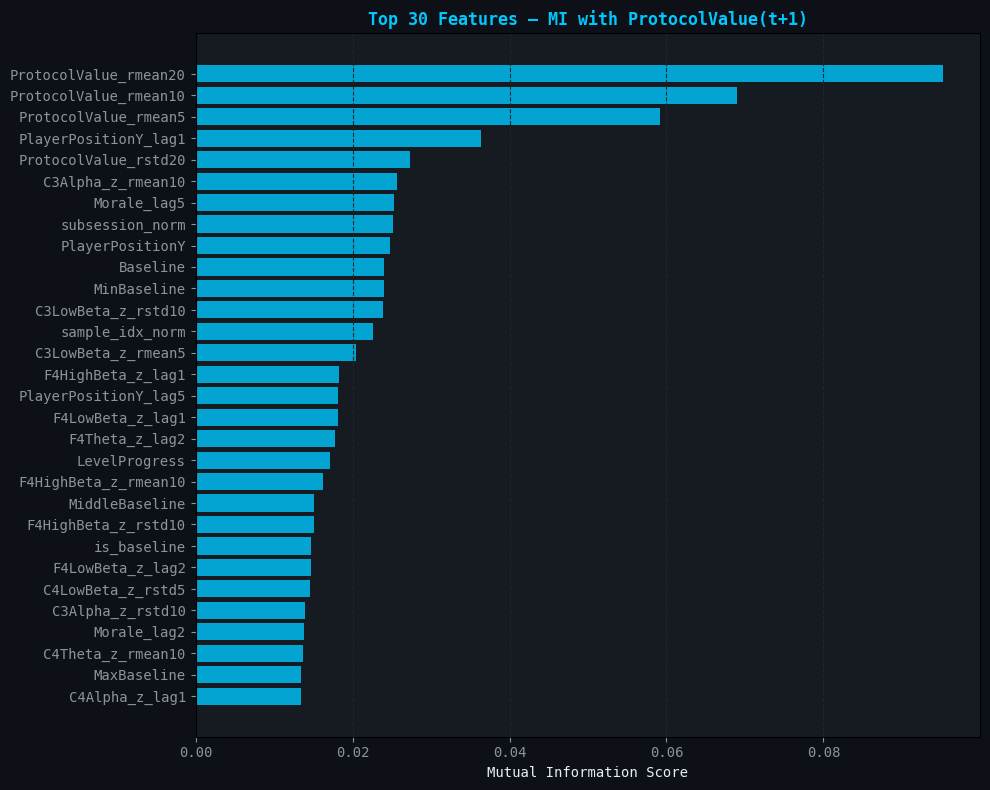

Top 15 features by MI:
              feature       mi
ProtocolValue_rmean20 0.095187
ProtocolValue_rmean10 0.069021
 ProtocolValue_rmean5 0.059200
 PlayerPositionY_lag1 0.036373
 ProtocolValue_rstd20 0.027325
    C3Alpha_z_rmean10 0.025608
          Morale_lag5 0.025272
      subsession_norm 0.025194
      PlayerPositionY 0.024797
             Baseline 0.023984
          MinBaseline 0.023975
   C3LowBeta_z_rstd10 0.023930
      sample_idx_norm 0.022638
   C3LowBeta_z_rmean5 0.020431
    F4HighBeta_z_lag1 0.018307


In [8]:
EXCLUDE = {TARGET, f'{TARGET}_next', SS_COL, SAMPLE_COL,
           'action','reward','session_type', *EEG_COLS}
FEATURE_COLS = [c for c in df_feat.select_dtypes(include=[np.number]).columns
                if c not in EXCLUDE]

game_df = df_feat[df_feat[SS_COL]>0][FEATURE_COLS+[f'{TARGET}_next']].dropna()
mi = mutual_info_regression(game_df[FEATURE_COLS], game_df[f'{TARGET}_next'], random_state=42)
mi_df = pd.DataFrame({'feature':FEATURE_COLS,'mi':mi}).sort_values('mi',ascending=False)

fig, ax = plt.subplots(figsize=(10,8))
top30 = mi_df.head(30)
ax.barh(top30['feature'][::-1], top30['mi'][::-1], color='#00c8ff', alpha=0.8)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 30 Features — MI with ProtocolValue(t+1)', color='#00c8ff', fontweight='bold')
ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance_mi.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Top 15 features by MI:')
print(mi_df.head(15).to_string(index=False))

## 8. Save

In [9]:
df_feat.to_parquet(PROCESSED_DIR/'features.parquet', index=False)

meta = {
    'target': TARGET, 'target_next': f'{TARGET}_next',
    'feature_cols': FEATURE_COLS, 'eeg_z_cols': EEG_Z,
    'game_cols': GAME_COLS, 'action_col': 'action', 'reward_col': 'reward',
    'n_actions': 3,
    'action_map': {'0':'Lower threshold','1':'Hold threshold','2':'Raise threshold'},
    'n_features': len(FEATURE_COLS),
}
(PROCESSED_DIR/'feature_meta.json').write_text(json.dumps(meta, indent=2))

print(f'Saved features.parquet: {df_feat.shape}')
print(f'Total feature columns: {len(FEATURE_COLS)}')

Saved features.parquet: (3549, 279)
Total feature columns: 246
